# 4주차 실습 · 비지도학습과 모델 선택
**피지컬AI응용 (MR347) · 2026-2 · 인하공업전문대학 컴퓨터시스템공학과**

강의 슬라이드의 실습 ①~④ 입니다. 데이터는 3주차와 같은 **온도·진동 → 고장** 데이터이고, 실습 ③ 을 위해 센서 5개짜리 표 `sensor5` 를 추가로 만듭니다.

| 실습 | 내용 | 코드 |
|---|---|---|
| ① | 정답을 숨기고 KMeans → 교차표로 정답과 비교 | 3줄 |
| ② | K 를 2~6으로 바꿔 관성·실루엣 보기 | 4줄 |
| ③ | 센서 5개를 PCA 로 2개로 눌러 산점도 | 4줄 |
| ④ | max_depth 1→8 훈련/시험 정확도 | 5줄 |

**규칙** — 데이터 준비 셀을 먼저 실행하고, 각 실습 셀은 직접 타이핑합니다. AI 사용 금지.


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, accuracy_score
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

print("준비 완료")


준비 완료


In [5]:
# ===== 데이터 준비 (그대로 실행하세요) =====
rng = np.random.default_rng(22)
n = 200
temp  = rng.uniform(15, 45, n)
vib   = rng.uniform(0, 5, n)
fault = (0.25*temp + 1.2*vib - 10 + rng.normal(0, 1, n) > 0).astype(int)
clf = pd.DataFrame({"온도": temp.round(1), "진동": vib.round(2), "고장": fault})

# 실습 ③ 용: 센서 5개짜리 표 (전류·소음은 진동에서 파생, 배터리는 무관)
rng2 = np.random.default_rng(7)
sensor5 = pd.DataFrame({
    "온도": temp,
    "진동": vib,
    "전류": 2 + 0.05*temp + 0.4*vib + rng2.normal(0, 0.3, n),
    "소음": 40 + 3*vib + rng2.normal(0, 2, n),
    "배터리": rng2.uniform(20, 100, n),
})

X = clf[["온도", "진동"]].values
y = clf["고장"].values
Xs = StandardScaler().fit_transform(X)
print(clf.head(3)); print(sensor5.shape)


     온도    진동  고장
0  26.0  0.27   0
1  21.0  2.02   0
2  17.7  0.38   0
(200, 5)


**실행 결과**
```
     온도    진동  고장
0  26.0  0.27   0
1  21.0  2.02   0
2  17.7  0.38   0
(200, 5)
```

---
### 실습 ① 정답을 숨기고 KMeans 돌리기

`Xs` 로 K=2 KMeans 를 학습하고, 군집 번호와 진짜 고장 여부를 **교차표**로 비교하세요. y 는 fit 에 넣지 않습니다.

> 💡 **힌트** — `km = KMeans(n_clusters=2, random_state=42).fit(Xs)` → `pd.crosstab(km.labels_, clf['고장'])`

**예상 출력**
```
실제   0   1
군집        
0   25  79
1   68  28
일치율: 0.735
```


In [8]:
# 여기에 코드를 쓰세요
km = KMeans(n_clusters=2, random_state=42).fit(Xs)
print(pd.crosstab(km.labels_, clf['고장'], rownames=['군집'], colnames=["실패"]))
print(f"일치율: {np.mean(km.labels_ == clf['고장'])}")


실패   0   1
군집        
0   25  79
1   68  28
일치율: 0.265


---
### 실습 ② K 를 바꿔 보기

K 를 2부터 8까지 바꾸며 **관성(inertia)** 과 **실루엣 점수** 를 출력하세요.
마지막에 한 문장으로 답하세요: *나라면 K 를 몇으로 하겠는가, 이유는?*

> 💡 **힌트** — `for k in range(2, 9):` 안에서 KMeans 학습 → `km.inertia_`, `silhouette_score(Xs, km.labels_)`

**예상 출력**
```
2 247.4 0.355
3 157.4 0.383
4 96.4 0.418
5 80.3 0.411
6 69.1 0.354
7 58.2 0.369
8 47.5 0.383
```


In [21]:
# 여기에 코드를 쓰세요
for k in range(2,7):
  km = KMeans(n_clusters=k, random_state=42).fit(Xs)
  sil = silhouette_score(Xs, km.labels_)
  print(k, round(km.inertia_, 1), round(sil, 3))

2 247.4 0.355
3 157.4 0.383
4 96.4 0.418
5 80.3 0.411
6 69.1 0.354


---
### 실습 ③ 센서 5개를 2개로 — PCA

`sensor5` 를 표준화한 뒤 `PCA(n_components=2)` 로 줄이고, 설명 분산 비율과 산점도(정답 색)를 출력하세요.

> 💡 **힌트** — `X5 = StandardScaler().fit_transform(sensor5.values)` → `Z = PCA(n_components=2).fit_transform(X5)` → `plt.scatter(Z[:,0], Z[:,1], c=y)`

**예상 결과** — 아래 숫자 출력 + 산점도
```
Z: (200, 2)
설명 분산 비율: [0.54 0.23]
성분 1 계수: [0.23 0.57 0.57 0.55 0.06]
```


(200, 2)
[0.54046689 0.22968244]


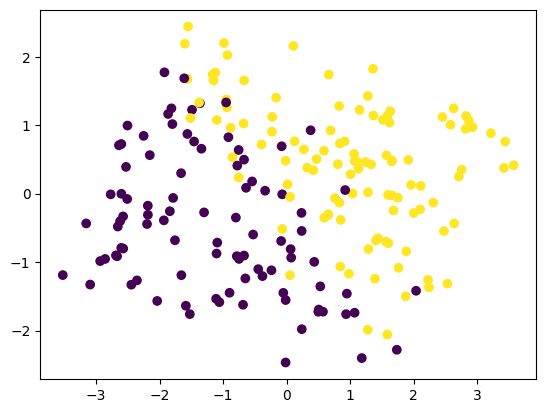

In [23]:
# 여기에 코드를 쓰세요

X5 = StandardScaler().fit_transform(sensor5.values)
pca = PCA(n_components=2)
Z = pca.fit_transform(X5)

print(Z.shape)
print(pca.explained_variance_ratio_)

plt.scatter(Z[:, 0], Z[:,1], c=clf["고장"])


---
### 실습 ④ 손잡이 돌려 보기 — max_depth

`X`, `y` 를 8:2 로 나눈 뒤, `max_depth` 를 1,2,3,4,5,6,8 로 바꾸며 **훈련 정확도와 시험 정확도**를 출력하세요.

> 💡 **힌트** — `for d in [1,2,3,4,5,6,8]:` 안에서 `DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_train, y_train)` → `.score(X_train, y_train)`, `.score(X_test, y_test)`

**예상 출력**
```
1 0.762 0.775
2 0.863 0.825
3 0.9 0.85
4 0.938 0.8
5 0.963 0.8
6 0.975 0.825
8 1.0 0.775
```


In [28]:
# 여기에 코드를 쓰세요
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
for d in [1,2,3,4,5,6,8]:
  dt = DecisionTreeClassifier(max_depth=d, random_state=42)
  dt.fit(X_train, y_train)

---
### 실습 ④-2 교차검증과 GridSearchCV (여유가 있으면)

같은 데이터에서 `cross_val_score(cv=5)` 로 로지스틱 회귀와 트리(max_depth=3)를 비교하고, `GridSearchCV` 로 최적 max_depth 를 찾으세요.

> 💡 **힌트** — `cross_val_score(model, X, y, cv=5).mean()` / `GridSearchCV(DecisionTreeClassifier(random_state=42), {'max_depth':[1,2,3,4,5,6,8,10]}, cv=5).fit(X_train, y_train)`

**예상 출력**
```
Logistic [0.925 0.825 0.975 0.9   0.9  ] 평균 0.905
Tree d3 [0.725 0.775 0.825 0.85  0.85 ] 평균 0.805
best: {'max_depth': 4} cv: 0.831 test: 0.8
```


In [32]:
# 여기에 코드를 쓰세요
from sklearn.model_selection import GridSearchCV
후보 = {"max_depth": [1,2,3,4,5,6,8,10]}
gs = GridSearchCV(DecisionTreeClassifier(random_state=42), 후보, cv=5)
gs.fit(X_train, y_train)

print(gs.best_params_)
print(round(gs.best_score_,3))
print(round(gs.score(X_test, y_test), 3))

{'max_depth': 4}
0.831
0.8
